## Exploratory Analysis

Here we wish to use our defined functions in [`data_loader.py`](data_loader.py) to do the following:
- Define a universe of US-based equities
- Retrieve adjusted prices in a specified date range
- Compute returns on the prices using log or simple returns
- Plot SPY and IVV then their correpsonding spread
- Compute return-correlation and price-correlation metrics for banks group

## Setup

First, we import the corresponding functions from `data_loader.py`. Next, we retrieve tickers from the banks and etf_pairs universes and then get prices and compute log returns on the prices.

In [57]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))

from data_loader import download_prices, compute_returns, get_universe

tickers = get_universe('banks') + get_universe('etf_pairs')
prices = download_prices(tickers, '2014-01-01', '2024-12-31')
print(prices.shape)
print(prices.head())
print(prices.isna().sum()) # Nans per ticker

returns = compute_returns(prices, method='log')
print(returns.describe()) # check stats


(2767, 10)
                  JPM        BAC          C        WFC          GS         MS  \
Date                                                                            
2014-01-02  41.982853  12.611904  38.515396  31.819029  139.700317  22.523537   
2014-01-03  42.307407  12.854744  39.348030  32.045193  140.695358  22.871952   
2014-01-06  42.552631  13.050583  39.650139  32.101742  141.658875  22.951801   
2014-01-07  42.062183  12.925247  39.922775  32.087601  140.805954  22.879213   
2014-01-08  42.458847  12.987911  40.386993  32.455124  140.924423  22.908253   

                   SPY         IVV        QQQ        XLK  
Date                                                      
2014-01-02  148.580231  149.032364  79.043648  15.225321  
2014-01-03  148.555908  148.967545  78.473038  15.152190  
2014-01-06  148.125427  148.562576  78.183174  15.126375  
2014-01-07  149.035156  149.477753  78.907784  15.264043  
2014-01-08  149.067612  149.558792  79.079842  15.264043  
JPM    0

## Checks

Next, we plot the SPY and IVV etf's as they track the same equities we expect their plots to be simular and corresponding the SPY - IVV spread to hover close to zero.

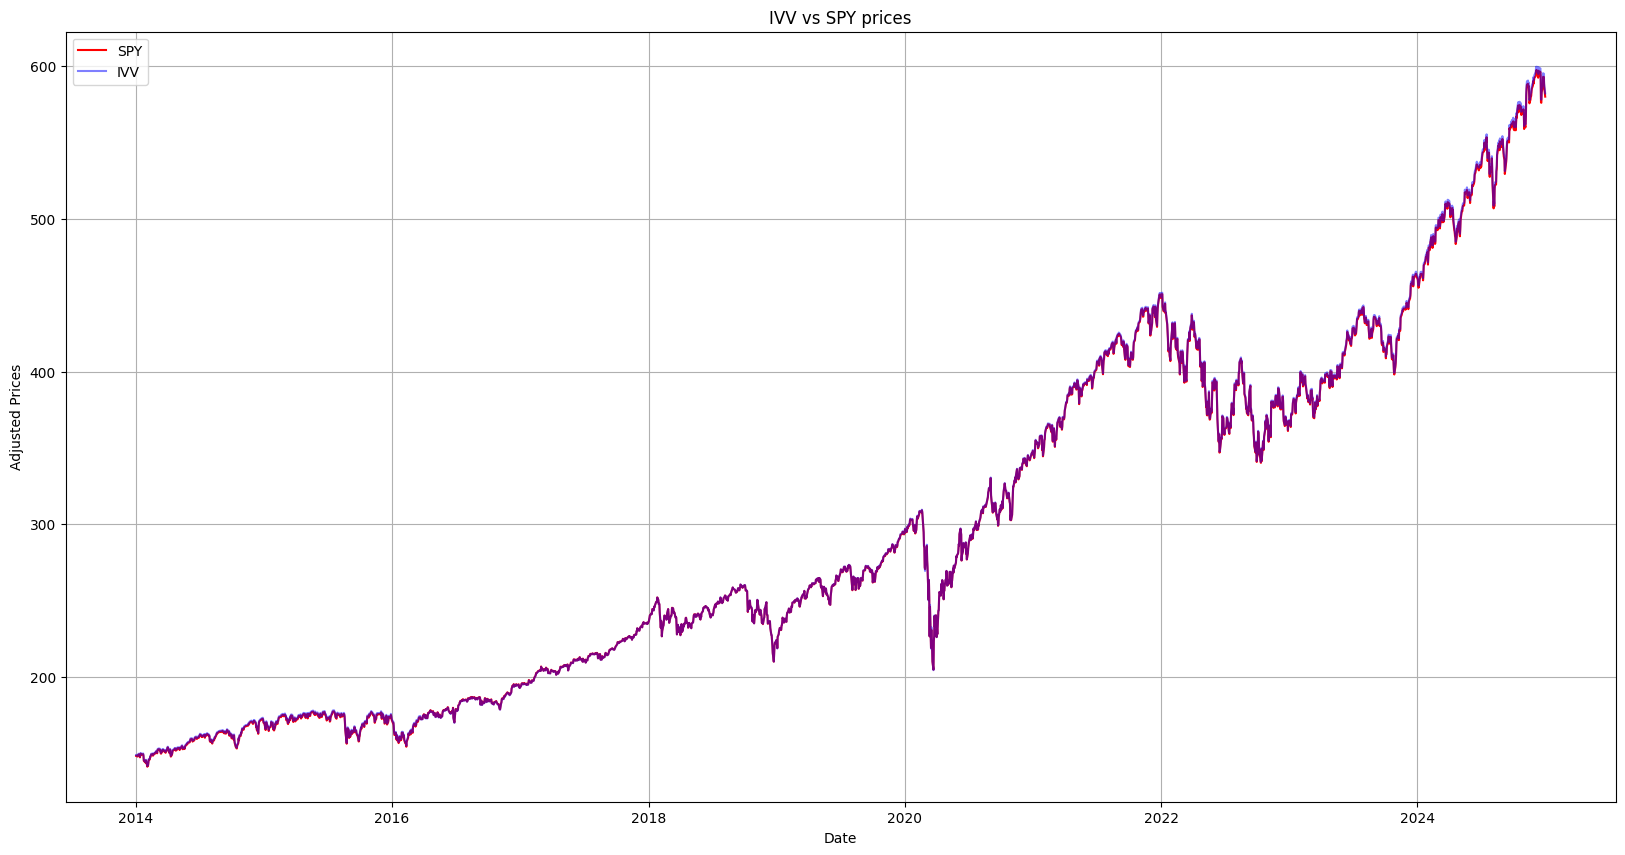

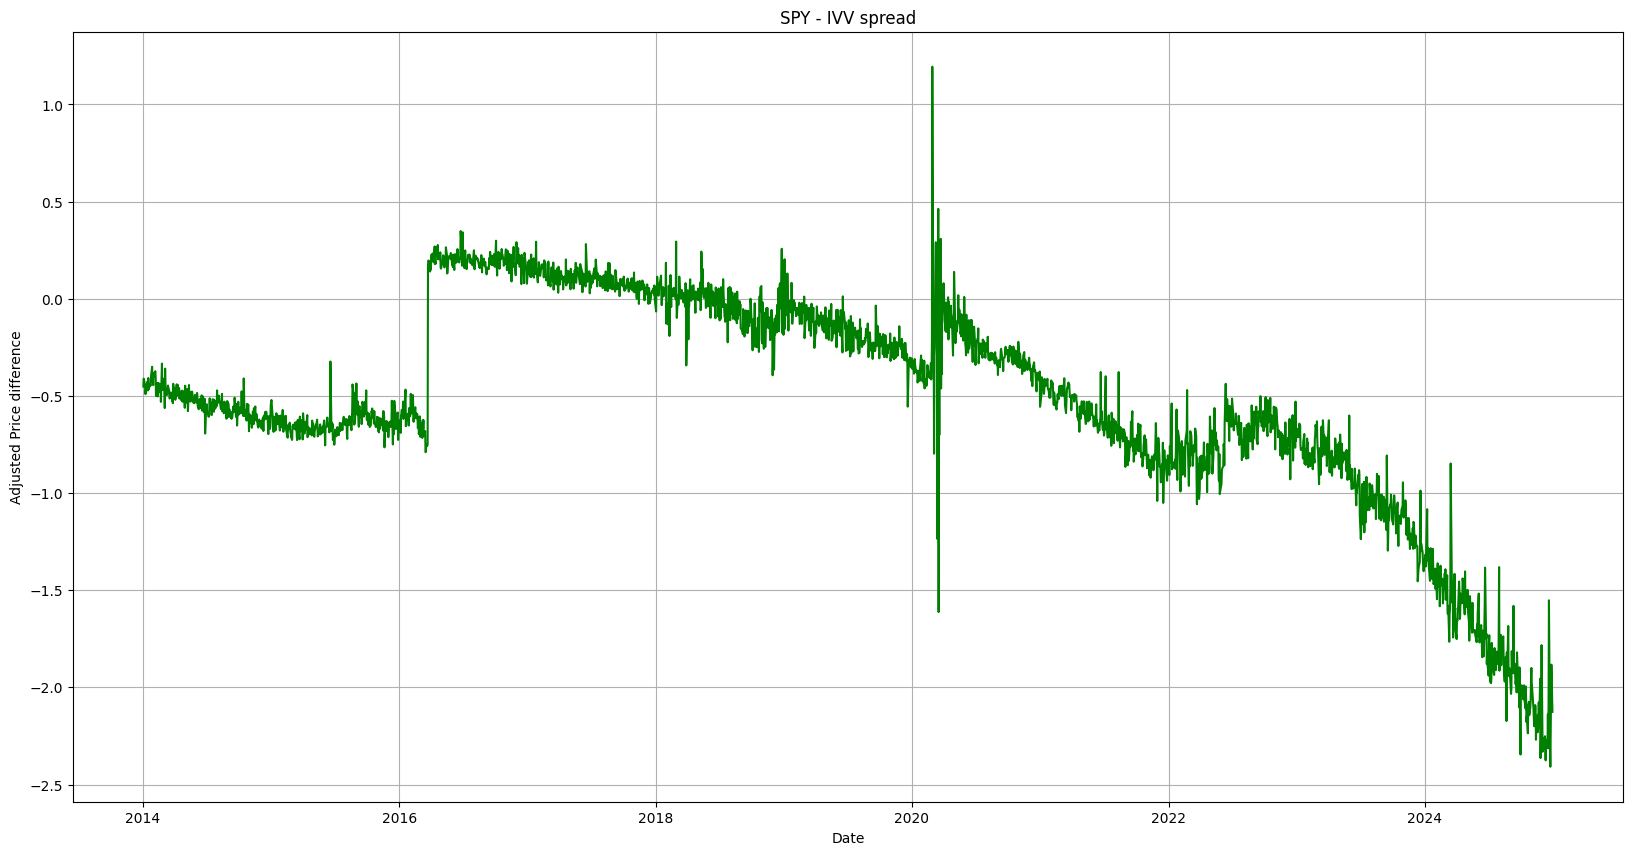

In [58]:
# Get both prices
spy = prices['SPY']
ivv = prices['IVV']

plt.figure(figsize=(20,10))
plt.plot(spy, label='SPY', color='red',)
plt.plot(ivv, label='IVV', color='blue',alpha=0.5)
plt.title('IVV vs SPY prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Prices')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(spy-ivv, label='SPY-IVV', color='green',)
plt.title('SPY - IVV spread')
plt.xlabel('Date')
plt.ylabel('Adjusted Price difference')
plt.grid(True)
plt.show()


From the above plots we note that even though SPY and IVV track the same fund, the spread shows that there is a clear non-constant mean with a negative trend downwards post 2016. This importantly shows that even if two etfs track the same index, they may not be cointegrated.

## Correlation

In this part we wish to investigate the correlation of returns between SPY and IVV. First we plot the ratio of prices to further examine the behaviour linking these two etfs.

<Axes: title={'center': 'SPY / IVV ratio'}, xlabel='Date'>

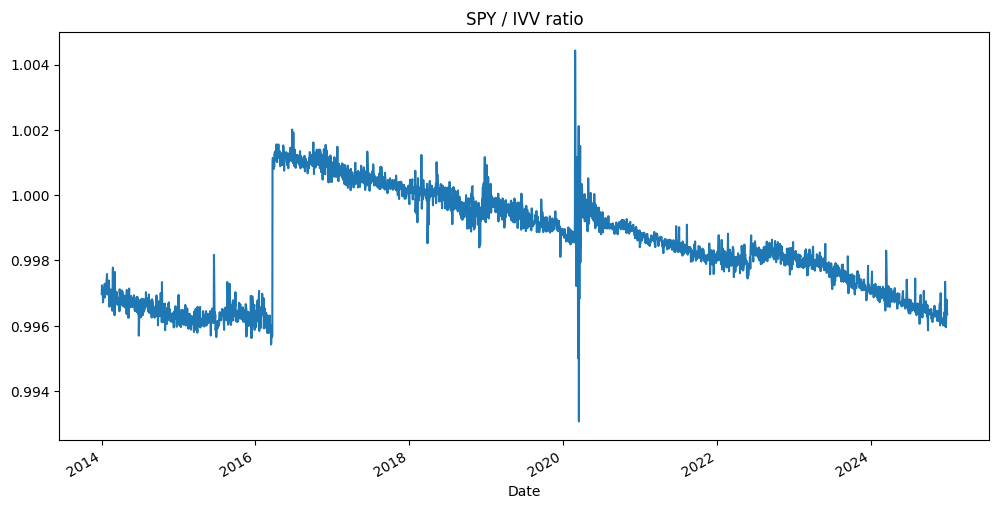

In [59]:
ratio = prices['SPY'] / prices['IVV']
ratio.plot(figsize=(12,6), title='SPY / IVV ratio')


In this plot, we see a similar pattern as in the SPY IVV spread, the trend moves downwards after 2016. One reason for the fact that SPY seems to be losing out over IVV in the long term is the expense ratio difference. When examining the expense ratios, we see IV has a significantly lower ratio of 0.03% compared to the 0.0945% of SPY. This allows higher dividends for IVV than from SPY and thus better performance than SPY.

On the other hand, computing the correlations between returns and prices will give us a sense of how these equities perform in regard to eachother.

          SPY       IVV
SPY  1.000000  0.999165
IVV  0.999165  1.000000
          SPY       IVV
SPY  1.000000  0.999995
IVV  0.999995  1.000000


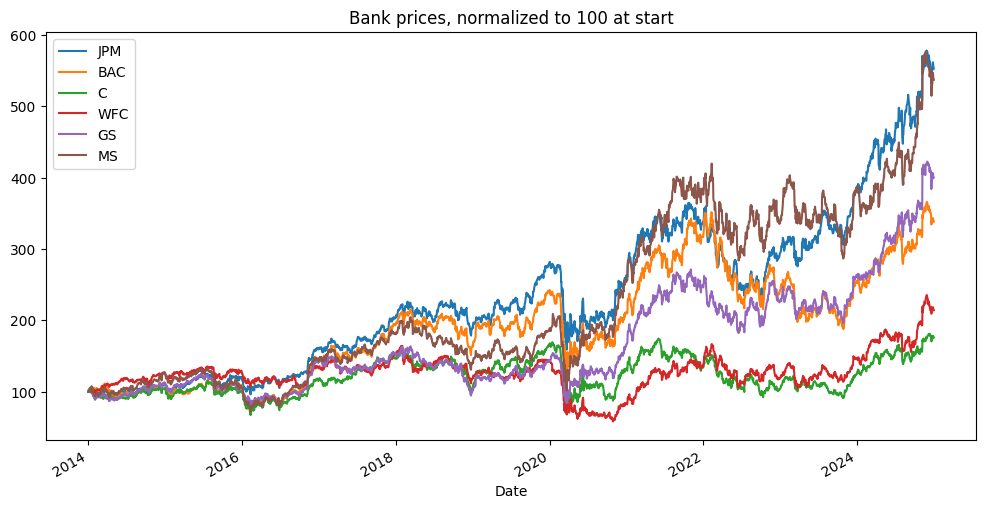

Return correlation:
      JPM   BAC     C   WFC    GS    MS
JPM  1.00  0.89  0.86  0.81  0.82  0.82
BAC  0.89  1.00  0.87  0.83  0.82  0.83
C    0.86  0.87  1.00  0.79  0.81  0.81
WFC  0.81  0.83  0.79  1.00  0.75  0.75
GS   0.82  0.82  0.81  0.75  1.00  0.86
MS   0.82  0.83  0.81  0.75  0.86  1.00

Price correlation:
      JPM   BAC     C   WFC    GS    MS
JPM  1.00  0.92  0.68  0.57  0.95  0.94
BAC  0.92  1.00  0.76  0.51  0.89  0.91
C    0.68  0.76  1.00  0.61  0.60  0.55
WFC  0.57  0.51  0.61  1.00  0.63  0.51
GS   0.95  0.89  0.60  0.63  1.00  0.97
MS   0.94  0.91  0.55  0.51  0.97  1.00


In [60]:
# Correlation of returns
print(returns[['SPY', 'IVV']].corr())

# Correlation of prices
print(prices[['SPY', 'IVV']].corr())

# Banks normalized prices
banks = get_universe('banks')
# Divide by initial position with .iloc[0] and * 100 to normalize to 100
normalized = prices[banks] / prices[banks].iloc[0] *100
normalized.plot(figsize=(12,6), title='Bank prices, normalized to 100 at start')
plt.show()

# Correlation matrices for banks
print("Return correlation:")
print(returns[banks].corr().round(2))
print("\nPrice correlation:")
print(prices[banks].corr().round(2))

